In [24]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Problem 4.2

Repeat the simulations and analyses in Example 4.1 and Example 4.2 with the following changes:

## Example 4.1

In [17]:
# Example 4.1 (Transcribed from R code in book)

# Made it a function call since I didn't want to copy it
def example41(n=100):
  # Time vector t
  t = np.arange(1, n+1)

  # Signal Generation
  x1 = 2 * np.cos(2 * np.pi * t * 6 / 100) + 3 * np.sin(2 * np.pi * t * 6 / 100)
  x2 = 4 * np.cos(2 * np.pi * t * 10 / 100) + 5 * np.sin(2 * np.pi * t * 10 / 100)
  x3 = 6 * np.cos(2 * np.pi * t * 40 / 100) + 7 * np.sin(2 * np.pi * t * 40 / 100)
  x = x1 + x2 + x3

  # Plot 4 Graphs in a grid
  fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
      r'$\omega = 6/100, A^2 = 13$',  # Title for (1,1)
      r'$\omega = 10/100, A^2 = 41$', # Title for (1,2)
      r'$\omega = 40/100, A^2 = 85$', # Title for (2,1)
      'Sum'                           # Title for (2,2)
    )
  )

  # Plot 1
  fig.add_trace(
      go.Scatter(x=t, y=x1, mode='lines', name='x1'),
      row=1, col=1
  )

  # Plot 2
  fig.add_trace(
      go.Scatter(x=t, y=x2, mode='lines', name='x2'),
      row=1, col=2
  )

  # Plot 3
  fig.add_trace(
      go.Scatter(x=t, y=x3, mode='lines', name='x3'),
      row=2, col=1
  )

  # Plot 4
  fig.add_trace(
      go.Scatter(x=t, y=x, mode='lines', name='x'),
      row=2, col=2
  )

  # Mirror the Y Limits shown in the book
  fig.update_yaxes(range=[-10, 10], row=1, col=1)
  fig.update_yaxes(range=[-10, 10], row=1, col=2)
  fig.update_yaxes(range=[-10, 10], row=2, col=1)
  fig.update_yaxes(range=[-20, 20], row=2, col=2)

  fig.update_layout(
      showlegend=False
  )

  fig.show()

example41()

## Example 4.2

In [18]:
# Example 4.2 (Transcribed from R code in book)

def example42(n=100):
  # Time vector t
  t = np.arange(1, n+1)

  # Signal Generation
  x1 = 2 * np.cos(2 * np.pi * t * 6 / 100) + 3 * np.sin(2 * np.pi * t * 6 / 100)
  x2 = 4 * np.cos(2 * np.pi * t * 10 / 100) + 5 * np.sin(2 * np.pi * t * 10 / 100)
  x3 = 6 * np.cos(2 * np.pi * t * 40 / 100) + 7 * np.sin(2 * np.pi * t * 40 / 100)
  x = x1 + x2 + x3

  # Fast Fourier Transform
  complex_fft = np.fft.fft(x)
  P = np.abs(2 * complex_fft / n)**2

  # Frequency labels
  Fr = np.arange(n) / n

  # Plot with Plotly
  fig = go.Figure()
  fig.add_trace(
      go.Scatter(
          x=Fr,
          y=P,
          mode='lines+markers',
          name='Periodogram'
      )
  )
  fig.update_layout(
      title='Scaled Periodogram',
      xaxis_title='Frequency',
      yaxis_title='Scaled Periodogram'
  )
  fig.show()

example42()

## Part (a)

Change the sample size to $n = 128$ and generate and plot the same series as in Example 4.1:
$$
x_{t1} = 2cos(2\pi .06t) + 3sin(2\pi .06t),\\
x_{t2} = 4cos(2\pi .10t) + 5sin(2\pi .10t),\\
x_{t3} = 6cos(2\pi .40t) + 7sin(2\pi .40t),\\
x_{t} = x_{t1} + x_{t2} + x_{t3}
$$

What is the major difference between these series and the series generated in Example 4.1? (Hint: The answer is fundamental. But if your answer is the series are longer, you may be punished severely.)

Hint, compare the width of the peaks between the cases of $n=100$ and $n=128$.

In [13]:
# Example above made into a function to reduce clutter
example41(n=128)

The time series is longer as prescribed, but when we look at the peaks, we can see that there are a differing amount of additional periods for each signal. For $x_{t1}$, we can see around ~1.5 more cycles, ~3.5 more cycles for $x_{t2}$, and ~5.5 more cycles for $x_{t3}$.

Other than that and the length, I'm quite sure what is different when directly looking at the graphs.

## Part (b)

As in Example 4.2, compute and plot the periodogram of the series, $x_t$, generated in (a) and comment.

In [19]:
example42(n=128)

Looking at the scaled periodogram, I can see that the additional cycles has some impact. The spikes in the the graph have changed a bit in both magnitude, location, and a slight transformation to the shape of the spike.

There are now slight slopes to the bases of the spikes at 0.06, 0.4, 0.6, and 0.94. And interestingly enough, they look symmetrical when centered around 0.5.

The corresponding peaks shifted:
- 0.06 -> 0.0625
- 0.1 -> 0.1016
- 0.4 -> 0.3984
- 0.6 -> 0.6016
- 0.9 -> 0.8984
- 0.94 -> 0.9375

And all of the magnitudes of the peaks have shrunk by differing amounts (2 to 13).

The reason for this is called spectral leakage due to the signal's true frequencies no longer aligning with the new $n$ causing power to leak into neighboring bins.

## Part (c)

Repeat the analyses of (a) and (b) but with $n=100$ (as in Example 4.1), and adding noise to $x_t$; that is
$$
x_t = x_{t1} + x_{t2} + x_{t3} + w_t
$$
where $w_t$ ~ iid N(0,25). That is, you should simulate and plot the data, and then plot the periodogram of $x_t$ and comment.

In [33]:
# Time vector t
t = np.arange(1, 101)

# Signal Generation
x1 = 2 * np.cos(2 * np.pi * t * 6 / 100) + 3 * np.sin(2 * np.pi * t * 6 / 100)
x2 = 4 * np.cos(2 * np.pi * t * 10 / 100) + 5 * np.sin(2 * np.pi * t * 10 / 100)
x3 = 6 * np.cos(2 * np.pi * t * 40 / 100) + 7 * np.sin(2 * np.pi * t * 40 / 100)
wt = np.random.normal(0, 5, 100)
x = x1 + x2 + x3 + wt

# Plot 5 Graphs in a grid
fig = make_subplots(
  rows=3, cols=2,
  subplot_titles=(
    r'$\omega = 6/100, A^2 = 13$',  # Title for (1,1)
    r'$\omega = 10/100, A^2 = 41$', # Title for (1,2)
    r'$\omega = 40/100, A^2 = 85$', # Title for (2,1)
    'White Noise',                  # Title for (2,2)
    'Sum'                           # Title for (3,1)
  )
)

# Plot 1
fig.add_trace(
    go.Scatter(x=t, y=x1, mode='lines', name='x1'),
    row=1, col=1
)

# Plot 2
fig.add_trace(
    go.Scatter(x=t, y=x2, mode='lines', name='x2'),
    row=1, col=2
)

# Plot 3
fig.add_trace(
    go.Scatter(x=t, y=x3, mode='lines', name='x3'),
    row=2, col=1
)

# Plot 4
fig.add_trace(
    go.Scatter(x=t, y=wt, mode='lines', name='w'),
    row=2, col=2
)

# Plot 5
fig.add_trace(
    go.Scatter(x=t, y=x, mode='lines', name='x'),
    row=3, col=1
)

# Mirror the Y Limits shown in the book
fig.update_yaxes(range=[-10, 10], row=1, col=1)
fig.update_yaxes(range=[-10, 10], row=1, col=2)
fig.update_yaxes(range=[-10, 10], row=2, col=1)
fig.update_yaxes(range=[-20, 20], row=2, col=2)
fig.update_yaxes(range=[-20, 20], row=3, col=1)

fig.update_layout(
    showlegend=False
)

fig.show()

In [34]:
# Example 4.2 (Transcribed from R code in book)

# Fast Fourier Transform
complex_fft = np.fft.fft(x)
P = np.abs(2 * complex_fft / 100)**2

# Frequency labels
Fr = np.arange(100) / 100

# Plot with Plotly
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=Fr,
        y=P,
        mode='lines+markers',
        name='Periodogram'
    )
)
fig.update_layout(
    title='Scaled Periodogram',
    xaxis_title='Frequency',
    yaxis_title='Scaled Periodogram'
)
fig.show()

Looking at the periodogram, I can see that while the white noise has ruffled up the previously flat baseline, it is way more legible than the time-domain graph.

The peaks in the periodogram are still easily visible and seems to be robust against the white noise.

## Part 2

Use `scipy.signal.periodogram` to calculate the periodogram of the sunspots data from `statsmodels`. Comment on your results, do they agree with your findings from Homework 5: ARMA models part 2?

In [21]:
# Addition imports
from scipy.signal import periodogram
import statsmodels.api as sm

# Get Sunspots Data
sunspots = sm.datasets.sunspots.load_pandas().data

# Periodogram
f, Pxx_den = periodogram(sunspots['SUNACTIVITY'], 1)

# Plot Periodogram
fig = go.Figure()
fig.add_trace(
  go.Scatter(
    x=f,
    y=Pxx_den,
    mode='lines+markers',
    name='Periodogram'
  )
)
fig.update_layout(
  title='Scaled Periodogram',
  xaxis_title='Frequency',
  yaxis_title='Scaled Periodogram'
)
fig.show()

Looking back on my findings in Homework 5 Part 2, I estimated ARMA(8,0).

This periodogram shows about 5 major peaks and I know from homework 5 that this is involved with a cyclical pattern. Since there doesn't need to be a one-to-one relation with the AR order and number of peaks but rather AR order > Number of peaks, I believe it agrees with my findings in homework 5.

## Part 3

Simulate a pure white noise process, an MA(1) process with $\theta = 0.75$, and an AR(1) process with $\phi = -0.75$. For all simulations, create 10,000 observations and then calculate and display the periodogram. Remark on your findings.

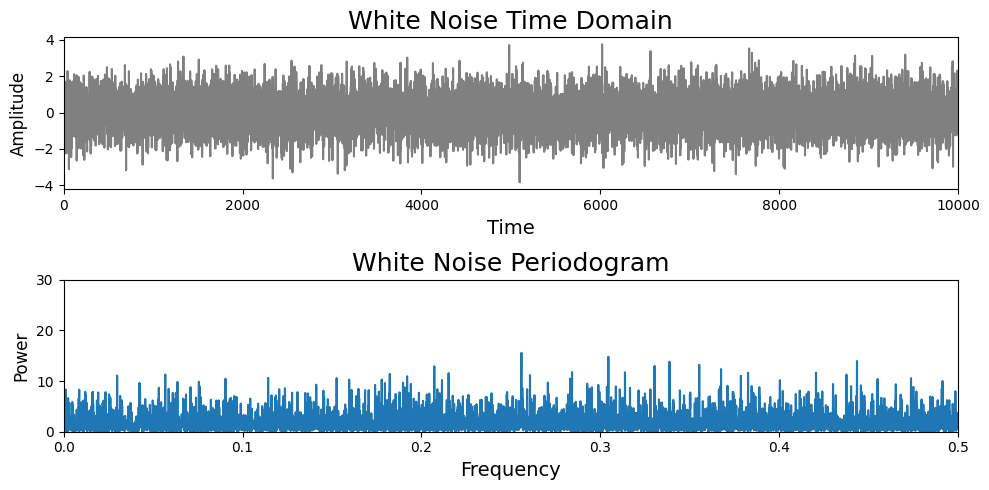

In [36]:
# Pure White Noise Process
# Citation, Taken and Modified from fourier_overview.ipynb provided during class
white_noise = np.random.normal(scale=1, size=10000)
freqs, PSD = periodogram(white_noise-white_noise.mean(), fs=1, scaling="density")

fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), sharex=False)
ax0.plot(np.arange(10000), white_noise, color="gray")
ax0.set_xlim(0, 10000)
ax1.plot(freqs, PSD)
ax1.set_xlim(0, 0.5)
ax1.set_ylim(0, 30)
ax0.set_title("White Noise Time Domain", fontsize=18)
ax1.set_title("White Noise Periodogram", fontsize=18)
ax0.set_ylabel("Amplitude", fontsize=12)
ax1.set_ylabel("Power", fontsize=12)
ax0.set_xlabel("Time", fontsize=14)
ax1.set_xlabel("Frequency", fontsize=14)
fig.tight_layout()
plt.show()

The periodogram of the simulated white noise series appears roughly uniform. There are peaks present, but none that stand out and any irregularities look to be randomly and evenly distributed.

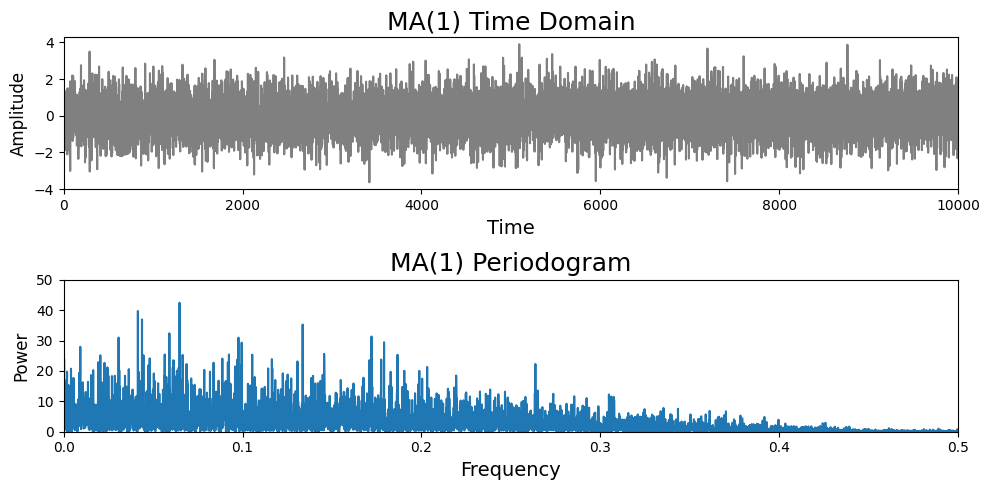

In [37]:
# MA(1) Process
# Citation, Taken and Modified from ar_ma_gen_demo.ipynb provided during class
white_noise = np.random.normal(size=10001, loc=0.0, scale=1.0)
theta = 0.75
ma1_numpy_sim = np.convolve(white_noise, [theta, 1], mode='valid')

# Get Periodogram, Taken and Modified from fourier_overview.ipynb provided during class
freqs, PSD = periodogram(ma1_numpy_sim-ma1_numpy_sim.mean(), fs=1, scaling="density")

fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), sharex=False)
ax0.plot(np.arange(10001), white_noise, color="gray")
ax0.set_xlim(0, 10001)
ax1.plot(freqs, PSD)
ax1.set_xlim(0, 0.5)
ax1.set_ylim(0, 50)
ax0.set_title("MA(1) Time Domain", fontsize=18)
ax1.set_title("MA(1) Periodogram", fontsize=18)
ax0.set_ylabel("Amplitude", fontsize=12)
ax1.set_ylabel("Power", fontsize=12)
ax0.set_xlabel("Time", fontsize=14)
ax1.set_xlabel("Frequency", fontsize=14)
fig.tight_layout()
plt.show()

The periodogram of a MA(1) process shows the expected shape with a higher spectral density at lower frequencies, decreasing towards higher frequencies. This makes sense with what we know about MA(1) where it has a short memory hence higher correlation with low lag.

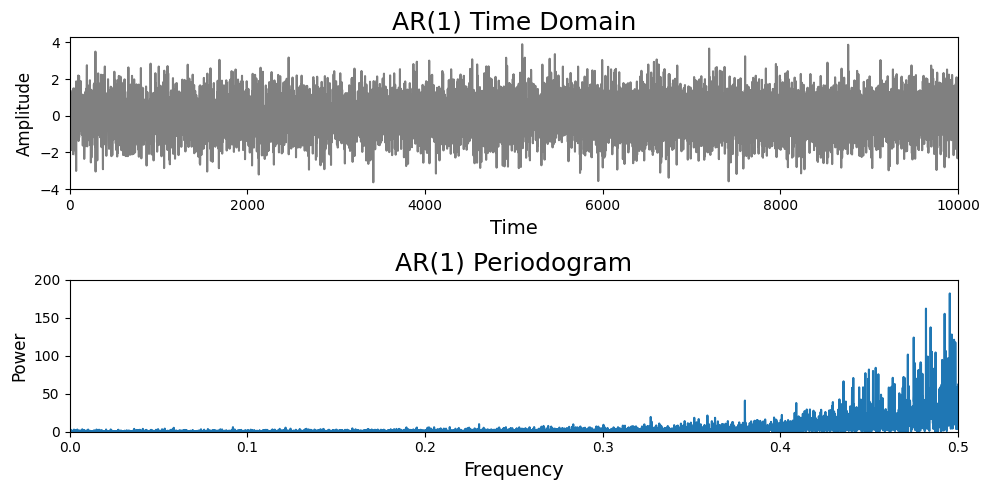

In [41]:
# AR(1) Process
# Citation, Taken and Modified from ar_ma_gen_demo.ipynb provided during class
ar1_numpy_sim = [0]
phi = -0.75
for idx in range(1, 10100):
  ar1_numpy_sim.append(phi * ar1_numpy_sim[idx-1] + np.random.normal(loc=0.0, scale=1.0))

# drop the first 100 simulated points as burn-in
ar1_numpy_sim = np.array(ar1_numpy_sim[100:])

# Get Periodogram, Taken and Modified from fourier_overview.ipynb provided during class
freqs, PSD = periodogram(ar1_numpy_sim-ar1_numpy_sim.mean(), fs=1, scaling="density")

fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), sharex=False)
ax0.plot(np.arange(10001), white_noise, color="gray")
ax0.set_xlim(0, 10001)
ax1.plot(freqs, PSD)
ax1.set_xlim(0, 0.5)
ax1.set_ylim(0, 200)
ax0.set_title("AR(1) Time Domain", fontsize=18)
ax1.set_title("AR(1) Periodogram", fontsize=18)
ax0.set_ylabel("Amplitude", fontsize=12)
ax1.set_ylabel("Power", fontsize=12)
ax0.set_xlabel("Time", fontsize=14)
ax1.set_xlabel("Frequency", fontsize=14)
fig.tight_layout()
plt.show()

Opposite to the MA(1), the AR(1) periodogram has increasing spectral density the higher the frequency goes. This also falls in line with what we've seen in AR(1) graphs as they are dominated by dense high-frequency oscillations and contain next to no slow-moving components.